<a href="https://colab.research.google.com/github/Irtisam99/Deep_Learning/blob/main/Deep_Feed_Forward_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu' )
device

device(type='cuda')

In [3]:
transform=transforms.Compose([
    transforms.ToTensor(),  # tensor format and in between (0-1)
    transforms.Normalize((0.5,),(0.5,))  #using mean and std it comes to (-1,1)
])

In [4]:
train_dataset=datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)
test_dataset=datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


In [5]:
train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True

)
test_loader=DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [16]:
data_iter=iter(train_loader)
images,label=next(data_iter)

print(len(images))
print(len(label))
print(images[63].shape)
print(label[63])

64
64
torch.Size([1, 28, 28])
tensor(4)


In [19]:
image=images[0].squeeze()
print(image.shape)
print(label[0])

torch.Size([28, 28])
tensor(0)


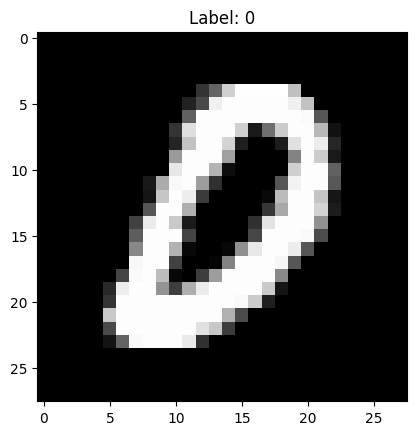

In [20]:
plt.imshow(image,cmap='gray')
plt.title(f"Label: {label[0].item()}")
plt.show()

In [22]:
class DeepFFN(nn.Module):
  def __init__(self):
    super(DeepFFN,self).__init__()
    self.model=nn.Sequential(
        #Block1
        nn.Flatten(),  #Converts multi dimensional array into a vector
        nn.Linear(28*28,256), #y=WX+b
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.3),

        #Block2
        nn.Linear(256,128),
        nn.ReLU(),

        #Block3
        nn.Linear(128,64),
        nn.ReLU(),

        nn.Linear(64,10),

    )

  def forward(self,x):
      return self.model(x)

model=DeepFFN().to(device)

In [23]:
(784+1)*256+(256+1)*128+(128+1)*64+(64+1)*10

242762

In [30]:
# parameters freezing: making the parameters untrainable i.e. no gradient descent will applicable to these parameters

total=sum(p.numel() for p in model.parameters())
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total}")
print(f"Trainable parameters: {trainable}")

243274

In [35]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [36]:
def train(model,loader):
  model.train()
  total_loss=0

  for images,label in loader:
    images,label=images.to(device),label.to(device)

    outputs=model(images)
    loss=criterion(outputs,label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss+=loss.item()  #The sum of all batch losses.

  return total_loss/len(loader) # Avergae loss accross all batches



In [37]:
def evaluate(model,loader):
  model.eval()
  correct=0
  total=0

  with torch.no_grad():
    for images, label in loader:
      images,label=images.to(device),label.to(device)

      outputs=model(images)
      _,predicted=torch.max(outputs,1)

      total+=label.size(0)
      correct+=(predicted==label).sum().item()

    return (correct/total)*100

In [39]:
epochs=5
for epoch in range(epochs):
  loss=train(model,train_loader)
  accuracy=evaluate(model,test_loader)

  print(f"Epoch {epoch+1}: Loss: {loss:.2f}, Accuracy: {accuracy:.2f}")

Epoch 1: Loss: 0.29, Accuracy: 96.55
Epoch 2: Loss: 0.14, Accuracy: 97.19
Epoch 3: Loss: 0.11, Accuracy: 97.56
Epoch 4: Loss: 0.09, Accuracy: 97.65
Epoch 5: Loss: 0.08, Accuracy: 97.86


In [ ]:
"""
When to use DFFN:
  examples are given in feature vector format i.e. x1, x2, x3, ..., x^n

  Core pipeline:
      Input > Linear > Activation > Dropout > Batch Normalization > ...> Output layer
"""